# Pipeline step 06 — Interhemispheric functional connectivity

**Purpose:** compute the sliding-window Pearson correlation between left and
right hMT+ time courses (window 6 s, or 7.5 s at TR = 2.5 s), plus the
V1-partial-correlation control, centred on the coherent/incoherent perceptual
switches from `data/bids_events/`. A 10 % correlation change defines a detected
switch.

**Manuscript outputs:** Figure 4 (correlation time courses), Figure 5 (%
switches detected), Figure 6 (time to detection), Figures S6/S7 (number of
switches), and the supplementary V1 partial-correlation control. This is the
current FC notebook; the earlier `step-06_fc.ipynb` (no V1 control) is in
`legacy/`.

# Functional connectivity analysis
Now fixating the number of seconds in the correlation window - 12 seconds around the transition

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Settings
# data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
# tc_dir = os.path.join(data_dir,'derivatives','timecourses')

data_dir = os.path.join("..", "data", "bids_events")
tc_dir = os.path.join("..", "data", "timecourses")

subject_list = [x for x in os.listdir(data_dir) if "sub-" in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ["AA", "UA"]
hrf_delay = 0  # in seconds
roi_list = ["left_mt", "right_mt", "left_v1", "right_v1"]

In [3]:
window_size_list = [6, 6, 6, 7.5]  # in seconds (for each tr)
window_size_tr_list = [12, 8, 6, 3]  # in tr (for each tr
step_size_list = [1, 1, 1, 1]  # in seconds (for each tr)

In [4]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(
    columns=[
        "subject",
        "tr",
        "run",
        "left_mt",
        "right_mt",
        "left_v1",
        "right_v1",
        "bilateral_mt",
        "bilateral_v1",
        "corr_mt",
        "corr_v1",
        "corr_mt_coherent",
        "corr_v1_coherent",
        "corr_mt_incoherent",
        "corr_v1_incoherent",
        "n_coherent",
        "n_incoherent",
        "n_total",
        "feedback_mt_indexoffirstone_coherent",  #'feedback_v1_indexoffirstone_coherent',
        "feedback_mt_indexoffirstone_incoherent",  #'feedback_v1_indexoffirstone_incoherent',
        "feedback_mt_bolean_coherent",  #'feedback_v1_bolean_coherent',
        "feedback_mt_bolean_incoherent",  #'feedback_v1_bolean_incoherent',
        "feedback_mt_coherent",  #'feedback_v1_coherent',
        "feedback_mt_incoherent",  #'feedback_v1_incoherent',
        "n_ps_detected_mt_coherent",  #'n_ps_detected_v1_coherent',
        "n_ps_detected_mt_incoherent",  #'n_ps_detected_v1_incoherent',
        "partial_corr_mt",
        "partial_corr_mt_coherent",
        "partial_corr_mt_incoherent",
        "feedback_mt_coherent_partial",  #'feedback_v1_coherent_partial',
        "feedback_mt_incoherent_partial",  #'feedback_v1_incoherent_partial',
        "feedback_mt_bolean_coherent_partial",  #'feedback_v1_bolean_coherent_partial',
        "feedback_mt_bolean_incoherent_partial",  #'feedback_v1_bolean_incoherent_partial',
        "feedback_mt_indexoffirstone_coherent_partial",  #'feedback_v1_indexoffirstone_coherent_partial',
        "feedback_mt_indexoffirstone_incoherent_partial",  #'feedback_v1_indexoffirstone_incoherent_partial'
        "n_ps_detected_mt_coherent_partial",  #'n_ps_detected_v1_coherent_partial',
        "n_ps_detected_mt_incoherent_partial",  #'n_ps_detected_v1_incoherent_partial'
    ]
)

# iterate over subjects
for ss, subject in enumerate(subject_list):
    print(f"Processing subject {subject} ({ss + 1}/{len(subject_list)})")

    # iterate over trs
    for tt, tr in enumerate(tr_list):
        window_size_tr = window_size_tr_list[tt]  # size of the correlation window in volumes
        step_size_tr = step_size_list[tt]  # step size of the correlation window in volumes

        # iterate over runs
        for rr, run in enumerate(run_list):
            # load timecourse
            tc_file = os.path.join(tc_dir, f"{subject}_{tr}_{run}_hp_std-psc_detrend.npy")
            tc = np.load(tc_file)

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:, 0:2], axis=1)
            tc_mean2 = np.mean(tc[:, 2:4], axis=1)

            # ----------------------------------------------------------------------------------------------------------------------------

            # initialize correlation vectors
            corr_mt = np.zeros(int((tc[:, 0].shape[0] - window_size_tr) / step_size_tr))
            corr_v1 = np.zeros(int((tc[:, 0].shape[0] - window_size_tr) / step_size_tr))

            partial_corr_mt = np.zeros(int((tc[:, 0].shape[0] - window_size_tr) / step_size_tr))

            # estimate windowed correlation between left and right mt
            for tt, tt_vol in enumerate(range(0, tc[:, 0].shape[0] - window_size_tr, step_size_tr)):
                corr_mt[tt] = np.corrcoef(tc[:, 0][tt_vol : tt_vol + window_size_tr], tc[:, 1][tt_vol : tt_vol + window_size_tr])[0, 1]
                corr_v1[tt] = np.corrcoef(tc[:, 2][tt_vol : tt_vol + window_size_tr], tc[:, 3][tt_vol : tt_vol + window_size_tr])[0, 1]

            # estimate partial correlation between left and right mt using left and right v1 as the control variables
            for tt, tt_vol in enumerate(range(0, tc[:, 0].shape[0] - window_size_tr, step_size_tr)):
                # create a dataframe with the timecourses
                df_tc = pd.DataFrame(
                    {
                        "left_mt": tc[:, 0][tt_vol : tt_vol + window_size_tr],
                        "right_mt": tc[:, 1][tt_vol : tt_vol + window_size_tr],
                        "left_v1": tc[:, 2][tt_vol : tt_vol + window_size_tr],
                        "right_v1": tc[:, 3][tt_vol : tt_vol + window_size_tr],
                    }
                )

                # fit the model for left_mt
                model = sm.OLS(df_tc["left_mt"], df_tc[["left_v1"]])
                results = model.fit()

                # get the residuals
                residuals_left_mt = results.resid

                # fit the model for right_mt
                model = sm.OLS(df_tc["right_mt"], df_tc[["right_v1"]])
                results = model.fit()

                # get the residuals
                residuals_right_mt = results.resid

                # calculate the correlation between the residuals
                partial_corr_mt[tt] = np.corrcoef(residuals_left_mt, residuals_right_mt)[0, 1]

            # ----------------------------------------------------------------------------------------------------------------------------

            # fetch events file
            task_label = f"task-{run}_acq-{round(tr * 1000):04}_run-1"
            events_file = os.path.join(data_dir, subject, "func", f"{subject}_{task_label}_events.tsv")

            events = pd.read_csv(events_file, sep="\t")

            # trim events to coherent and incoherent trial_types
            events = events.loc[events["trial_type"].isin(["coherent", "incoherent"])]
            events = events.reset_index(drop=True)

            # trim events with duration < 7.5 seconds
            events = events.loc[events["duration"] >= 7.5]
            events = events.reset_index(drop=True)

            # get the indexes (based on the TR) for all coherent and incoherent trials
            coherent_idx = events.loc[events["trial_type"] == "coherent"]["onset"].values / tr
            coherent_idx = [int(x) for x in coherent_idx]
            incoherent_idx = events.loc[events["trial_type"] == "incoherent"]["onset"].values / tr
            incoherent_idx = [int(x) for x in incoherent_idx]

            # number of coherent trials
            n_coherent = len(coherent_idx)
            n_incoherent = len(incoherent_idx)
            n_total = n_coherent + n_incoherent

            # ----------------------------------------------------------------------------------------------------------------------------

            # initialize correlation vectors for coherent and incoherent trials
            corr_mt_coherent = np.zeros((n_coherent, window_size_tr * 2 + 1))
            corr_v1_coherent = np.zeros((n_coherent, window_size_tr * 2 + 1))
            partial_corr_mt_coherent = np.zeros((n_coherent, window_size_tr * 2 + 1))

            corr_mt_incoherent = np.zeros((n_incoherent, window_size_tr * 2 + 1))
            corr_v1_incoherent = np.zeros((n_incoherent, window_size_tr * 2 + 1))
            partial_corr_mt_incoherent = np.zeros((n_incoherent, window_size_tr * 2 + 1))

            # initalize feedback signal vectors
            n_points_to_consider = window_size_tr * 2 - 1
            feedback_mt_coherent = np.zeros((n_coherent, n_points_to_consider))
            feedback_mt_bolean_coherent = np.zeros((n_coherent, n_points_to_consider))
            feedback_mt_indexoffirstone_coherent = np.zeros((n_coherent, 1))
            feedback_mt_incoherent = np.zeros((n_incoherent, n_points_to_consider))
            feedback_mt_bolean_incoherent = np.zeros((n_incoherent, n_points_to_consider))
            feedback_mt_indexoffirstone_incoherent = np.zeros((n_incoherent, 1))
            feedback_mt_coherent_partial = np.zeros((n_coherent, n_points_to_consider))
            feedback_mt_bolean_coherent_partial = np.zeros((n_coherent, n_points_to_consider))
            feedback_mt_indexoffirstone_coherent_partial = np.zeros((n_coherent, 1))
            feedback_mt_incoherent_partial = np.zeros((n_incoherent, n_points_to_consider))
            feedback_mt_bolean_incoherent_partial = np.zeros((n_incoherent, n_points_to_consider))
            feedback_mt_indexoffirstone_incoherent_partial = np.zeros((n_incoherent, 1))

            # feedback_v1_coherent = np.zeros((n_coherent,n_points_to_consider))
            # feedback_v1_bolean_coherent = np.zeros((n_coherent,n_points_to_consider))
            # feedback_v1_indexoffirstone_coherent = np.zeros((n_coherent,1))
            # feedback_v1_incoherent = np.zeros((n_incoherent,n_points_to_consider))
            # feedback_v1_bolean_incoherent = np.zeros((n_incoherent,n_points_to_consider))
            # feedback_v1_indexoffirstone_incoherent = np.zeros((n_incoherent,1))

            # iterate on the number of coherent trials
            for jj, coh_idx in enumerate(coherent_idx):
                # left_mt timecourse
                a = tc[:, 0][coh_idx - window_size_tr : coh_idx + window_size_tr * 2]
                # right_mt timecourse
                b = tc[:, 1][coh_idx - window_size_tr : coh_idx + window_size_tr * 2]
                # left_v1 timecourse
                c = tc[:, 2][coh_idx - window_size_tr : coh_idx + window_size_tr * 2]
                # right_v1 timecourse
                d = tc[:, 3][coh_idx - window_size_tr : coh_idx + window_size_tr * 2]

                # correlation per window of window_size_tr
                for kk in range(0, window_size_tr * 2 + 1):
                    corr_mt_coherent[jj, kk] = np.corrcoef(a[kk : kk + window_size_tr], b[kk : kk + window_size_tr])[0, 1]
                    corr_v1_coherent[jj, kk] = np.corrcoef(c[kk : kk + window_size_tr], d[kk : kk + window_size_tr])[0, 1]

                    # estimate partial correlation between left and right mt using left or right v1 as the control variables

                    # fit the model for left_mt
                    model = sm.OLS(a[kk : kk + window_size_tr], c[kk : kk + window_size_tr])
                    results = model.fit()

                    # get the residuals
                    residuals_left_mt = results.resid

                    # fit the model for right_mt
                    model = sm.OLS(b[kk : kk + window_size_tr], d[kk : kk + window_size_tr])
                    results = model.fit()
                    # get the residuals
                    residuals_right_mt = results.resid

                    # calculate the correlation between the residuals
                    partial_corr_mt_coherent[jj, kk] = np.corrcoef(residuals_left_mt, residuals_right_mt)[0, 1]

                # estimate feedback signal - variation of correlation in relation to the 2nd correlation window (the first that includes the perceptual switch volume)
                feedback_mt_coherent[jj, :] = (corr_mt_coherent[jj, 1:-1] - corr_mt_coherent[jj, 1]) / corr_mt_coherent[jj, 1]
                feedback_mt_bolean_coherent[jj, :] = feedback_mt_coherent[jj, :] > 0.1

                # estimate feedback signal with the partial correlation
                feedback_mt_coherent_partial[jj, :] = (
                    partial_corr_mt_coherent[jj, 1:-1] - partial_corr_mt_coherent[jj, 1]
                ) / partial_corr_mt_coherent[jj, 1]
                feedback_mt_bolean_coherent_partial[jj, :] = feedback_mt_coherent_partial[jj, :] > 0.1

                # feedback_v1_coherent[jj,:] = (corr_v1_coherent[jj,1:-1] - corr_v1_coherent[jj,1]) / corr_v1_coherent[jj,1]
                # feedback_v1_bolean_coherent[jj,:] = feedback_v1_coherent[jj,:] > 0.1

                # if feedback_mt_bolean_coherent is not all zeros, find the index of the first one and save it to feedback_mt_indexoffirstone_coherent
                if np.sum(feedback_mt_bolean_coherent[jj]) > 0:
                    feedback_mt_indexoffirstone_coherent[jj] = np.argmax(feedback_mt_bolean_coherent[jj])
                else:
                    feedback_mt_indexoffirstone_coherent[jj] = 0

                if np.sum(feedback_mt_bolean_coherent_partial[jj]) > 0:
                    feedback_mt_indexoffirstone_coherent_partial[jj] = np.argmax(feedback_mt_bolean_coherent_partial[jj])
                else:
                    feedback_mt_indexoffirstone_coherent_partial[jj] = 0

                # if np.sum(feedback_v1_bolean_coherent[jj]) > 0:
                #     feedback_v1_indexoffirstone_coherent[jj] = np.argmax(feedback_v1_bolean_coherent[jj])

            # iterate on the number of incoherent trials
            for jj, incoh_idx in enumerate(incoherent_idx):
                # left_mt timecourse
                a = tc[:, 0][incoh_idx - window_size_tr : incoh_idx + window_size_tr * 2]
                # right_mt timecourse
                b = tc[:, 1][incoh_idx - window_size_tr : incoh_idx + window_size_tr * 2]
                # left_v1 timecourse
                c = tc[:, 2][incoh_idx - window_size_tr : incoh_idx + window_size_tr * 2]
                # right_v1 timecourse
                d = tc[:, 3][incoh_idx - window_size_tr : incoh_idx + window_size_tr * 2]

                # correlation per window of window_size_tr
                for kk in range(0, window_size_tr * 2 + 1):
                    corr_mt_incoherent[jj, kk] = np.corrcoef(a[kk : kk + window_size_tr], b[kk : kk + window_size_tr])[0, 1]
                    corr_v1_incoherent[jj, kk] = np.corrcoef(c[kk : kk + window_size_tr], d[kk : kk + window_size_tr])[0, 1]

                    # estimate partial correlation between left and right mt using left and right v1 as the control variables
                    # fit the model for left_mt
                    model = sm.OLS(a[kk : kk + window_size_tr], c[kk : kk + window_size_tr])
                    results = model.fit()

                    # get the residuals
                    residuals_left_mt = results.resid

                    # fit the model for right_mt
                    model = sm.OLS(b[kk : kk + window_size_tr], d[kk : kk + window_size_tr])
                    results = model.fit()
                    # get the residuals
                    residuals_right_mt = results.resid

                    # calculate the correlation between the residuals
                    partial_corr_mt_incoherent[jj, kk] = np.corrcoef(residuals_left_mt, residuals_right_mt)[0, 1]

                # estimate feedback signal - variation of correlation in relation to the 2nd correlation window (the first that includes the perceptual switch volume)
                feedback_mt_incoherent[jj, :] = (corr_mt_incoherent[jj, 1:-1] - corr_mt_incoherent[jj, 1]) / corr_mt_incoherent[jj, 1]
                feedback_mt_bolean_incoherent[jj, :] = feedback_mt_incoherent[jj, :] < -0.1

                # estimate feedback signal with the partial correlation
                feedback_mt_incoherent_partial[jj, :] = (
                    partial_corr_mt_incoherent[jj, 1:-1] - partial_corr_mt_incoherent[jj, 1]
                ) / partial_corr_mt_incoherent[jj, 1]
                feedback_mt_bolean_incoherent_partial[jj, :] = feedback_mt_incoherent_partial[jj, :] < -0.1

                # feedback_v1_incoherent[jj,:] = (corr_v1_incoherent[jj,1:-1] - corr_v1_incoherent[jj,1]) / corr_v1_incoherent[jj,1]
                # feedback_v1_bolean_incoherent[jj,:] = feedback_v1_incoherent[jj,:] < -0.1

                # if feedback_mt_bolean_incoherent is not all zeros, find the index of the first one and save it to feedback_mt_indexoffirstone_incoherent
                if np.sum(feedback_mt_bolean_incoherent[jj]) > 0:
                    feedback_mt_indexoffirstone_incoherent[jj] = np.argmax(feedback_mt_bolean_incoherent[jj])
                else:
                    feedback_mt_indexoffirstone_incoherent[jj] = 0

                if np.sum(feedback_mt_bolean_incoherent_partial[jj]) > 0:
                    feedback_mt_indexoffirstone_incoherent_partial[jj] = np.argmax(feedback_mt_bolean_incoherent_partial[jj])
                else:
                    feedback_mt_indexoffirstone_incoherent_partial[jj] = 0

                # if np.sum(feedback_v1_bolean_incoherent[jj]) > 0:
                #     feedback_v1_indexoffirstone_incoherent[jj] = np.argmax(feedback_v1_bolean_incoherent[jj])

            # ----------------------------------------------------------------------------------------------------------------------------

            # calculate % of detected perceptual switches - the number of non zero values in feedback_mt_indexoffirstone_coherent divided by n_coherent
            n_ps_detected_mt_coherent, n_ps_detected_v1_coherent, n_ps_detected_mt_incoherent, n_ps_detected_v1_incoherent = 0, 0, 0, 0
            (
                n_ps_detected_mt_coherent_partial,
                n_ps_detected_v1_coherent_partial,
                n_ps_detected_mt_incoherent_partial,
                n_ps_detected_v1_incoherent_partial,
            ) = 0, 0, 0, 0

            if np.sum(feedback_mt_indexoffirstone_coherent > 0) > 0:
                n_ps_detected_mt_coherent = np.sum(feedback_mt_indexoffirstone_coherent > 0) / n_coherent

            if np.sum(feedback_mt_indexoffirstone_incoherent > 0) > 0:
                n_ps_detected_mt_incoherent = np.sum(feedback_mt_indexoffirstone_incoherent > 0) / n_incoherent

            if np.sum(feedback_mt_indexoffirstone_coherent_partial > 0) > 0:
                n_ps_detected_mt_coherent_partial = np.sum(feedback_mt_indexoffirstone_coherent_partial > 0) / n_coherent

            if np.sum(feedback_mt_indexoffirstone_incoherent_partial > 0) > 0:
                n_ps_detected_mt_incoherent_partial = np.sum(feedback_mt_indexoffirstone_incoherent_partial > 0) / n_incoherent

            # n_ps_detected_v1_coherent =   np.sum(feedback_v1_indexoffirstone_coherent > 0) / n_coherent
            # n_ps_detected_v1_incoherent = np.sum(feedback_v1_indexoffirstone_incoherent > 0) / n_incoherent

            # add row to dataframe
            df.loc[len(df)] = [
                subject,
                tr,
                run,
                tc[:, 0],
                tc[:, 1],
                tc[:, 2],
                tc[:, 3],
                tc_mean1,
                tc_mean2,
                corr_mt,
                corr_v1,
                corr_mt_coherent,
                corr_v1_coherent,
                corr_mt_incoherent,
                corr_v1_incoherent,
                n_coherent,
                n_incoherent,
                n_total,
                feedback_mt_indexoffirstone_coherent,  # feedback_v1_indexoffirstone_coherent,
                feedback_mt_indexoffirstone_incoherent,  # feedback_v1_indexoffirstone_incoherent,
                feedback_mt_bolean_coherent,  # feedback_v1_bolean_coherent,
                feedback_mt_bolean_incoherent,  # feedback_v1_bolean_incoherent,
                feedback_mt_coherent,  # feedback_v1_coherent,
                feedback_mt_incoherent,  # feedback_v1_incoherent,
                n_ps_detected_mt_coherent,  # n_ps_detected_v1_coherent,
                n_ps_detected_mt_incoherent,  # n_ps_detected_v1_incoherent
                partial_corr_mt,
                partial_corr_mt_coherent,
                partial_corr_mt_incoherent,
                feedback_mt_coherent_partial,  # feedback_v1_coherent_partial,
                feedback_mt_incoherent_partial,  # feedback_v1_incoherent_partial,
                feedback_mt_bolean_coherent_partial,  # feedback_v1_bolean_coherent_partial,
                feedback_mt_bolean_incoherent_partial,  # feedback_v1_bolean_incoherent_partial,
                feedback_mt_indexoffirstone_coherent_partial,  # feedback_v1_indexoffirstone_coherent_partial,
                feedback_mt_indexoffirstone_incoherent_partial,  # feedback_v1_indexoffirstone_incoherent_partial
                n_ps_detected_mt_coherent_partial,  # n_ps_detected_v1_coherent_partial,
                n_ps_detected_mt_incoherent_partial,  # n_ps_detected_v1_incoherent_partial
            ]

roi_list = ["left_mt", "right_mt", "left_v1", "right_v1", "bilateral_mt", "bilateral_v1"]

Processing subject sub-01 (1/15)
Processing subject sub-02 (2/15)
Processing subject sub-03 (3/15)
Processing subject sub-05 (4/15)
Processing subject sub-06 (5/15)
Processing subject sub-07 (6/15)
Processing subject sub-08 (7/15)
Processing subject sub-10 (8/15)
Processing subject sub-11 (9/15)
Processing subject sub-12 (10/15)
Processing subject sub-15 (11/15)
Processing subject sub-16 (12/15)
Processing subject sub-21 (13/15)
Processing subject sub-22 (14/15)
Processing subject sub-23 (15/15)


In [5]:
df.head()

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1,corr_mt,...,partial_corr_mt_coherent,partial_corr_mt_incoherent,feedback_mt_coherent_partial,feedback_mt_incoherent_partial,feedback_mt_bolean_coherent_partial,feedback_mt_bolean_incoherent_partial,feedback_mt_indexoffirstone_coherent_partial,feedback_mt_indexoffirstone_incoherent_partial,n_ps_detected_mt_coherent_partial,n_ps_detected_mt_incoherent_partial
0,sub-01,0.50,AA,"[-0.05384694, -0.6617026, -0.8346616, 0.089309...","[-0.09306835, -0.4169008, -0.7659277, 0.518666...","[0.10881213, 0.009274892, -0.5945296, -0.61654...","[0.02831542, 0.17118485, -0.68217134, -0.51357...","[-0.07345764, -0.5393017, -0.80029464, 0.30398...","[0.068563774, 0.09022987, -0.6383505, -0.56506...","[0.8839870894895893, 0.8756538517740642, 0.844...",...,"[[0.3765155687171677, 0.3540306876730976, 0.43...","[[0.8997132104941022, 0.9230385659158421, 0.94...","[[0.0, 0.24032293768984087, -0.251118970677154...","[[0.0, 0.02553915297941516, 0.0173798564546193...","[[0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[1.0], [9.0], [10.0], [8.0], [0.0], [0.0], [2...","[[11.0], [1.0]]",0.714286,1.000000
1,sub-01,0.50,UA,"[-0.22502376, -0.75862014, -0.81892, 0.6557168...","[-0.29588887, -0.6328848, -1.0537118, -0.29287...","[0.007993267, 0.022420743, -0.31263652, -0.666...","[-0.061439723, -0.097172484, -0.0958057, -0.54...","[-0.26045632, -0.6957525, -0.9363159, 0.181421...","[-0.026723228, -0.03737587, -0.20422111, -0.60...","[0.7666045156731345, 0.7498217678375372, 0.712...",...,"[[0.6815652376030283, 0.6823024315911422, 0.67...","[[0.7257563576162498, 0.6774593267221463, 0.64...","[[0.0, -0.016112074043175464, -0.1099024236214...","[[0.0, -0.04401627079399821, -0.08848828821298...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0,...","[[11.0], [21.0], [0.0], [21.0], [1.0], [8.0], ...","[[3.0], [7.0]]",0.857143,1.000000
2,sub-01,0.75,AA,"[0.12856638, -0.053825486, -0.7271523, -0.4753...","[0.17880233, 0.55607826, 0.2511821, -0.4758813...","[0.16492228, -0.36640495, -0.7682638, -0.83934...","[0.042525895, -0.3536918, -0.9582592, -0.45344...","[0.15368435, 0.25112638, -0.23798509, -0.47562...","[0.10372409, -0.36004835, -0.8632615, -0.64639...","[0.44013013319828825, 0.10890609940679236, -0....",...,"[[0.8109310735056853, 0.8240868296559821, 0.73...","[[0.827815902414217, 0.6360940879235368, 0.609...","[[0.0, -0.10868291918733079, -0.08508770669585...","[[0.0, -0.04168475560137379, 0.048928867968740...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[[9.0], [1.0], [0.0], [3.0], [9.0], [3.0], [1.0]]","[[6.0], [2.0], [4.0], [1.0], [4.0], [0.0]]",0.857143,0.833333
3,sub-01,0.75,UA,"[-0.1484935, -0.16956916, 0.079313174, -0.1769...","[-0.14745189, -0.15049157, 0.3577576, 0.024255...","[0.06832045, 0.29584754, -1.2515142, -0.786156...","[-0.031186417, 0.1780903, -0.8298843, -0.43459...","[-0.1479727, -0.16003036, 0.2185354, -0.076326...","[0.018567018, 0.23696892, -1.0406992, -0.61037...","[0.7188944508984093, 0.7560653916968808, 0.675...",...,"[[0.868273523655972, 0.8038333426067871, 0.839...","[[-0.5060616240108581, 0.2873347577455477, 0.5...","[[0.0, 0.044180910753081726, 0.031891337960358...","[[0.0, 0.7623985005522745, 2.0098539033975773,...","[[0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[3.0], [1.0], [12.0], [2.0], [8.0], [1.0], [0...","[[0.0], [2.0], [11.0], [1.0], [5.0], [1.0]]",0.857143,0.833333
4,sub-01,1.00,AA,"[0.299048, -0.9627552, -0.7164124, -0.7221738,...","[0.16075306, -0.43556026, -0.5292616, -0.61659...","[0.14598076, -1.2321407, -1.0398556, -0.396341...","[0.12612383, -0.6788299, -0.68316454, -0.29122...","[0.22990054, -0.6991577, -0.622837, -0.669382,...","[0.1360523, -0.9554853, -0.86151004, -0.343782...","[0.8866784914243659, 0.5815772076070274,

Text(0.5, 0.98, 'Subject sub-01, TR 2.5 s, Window size 12 vols, Step size 1 vols')

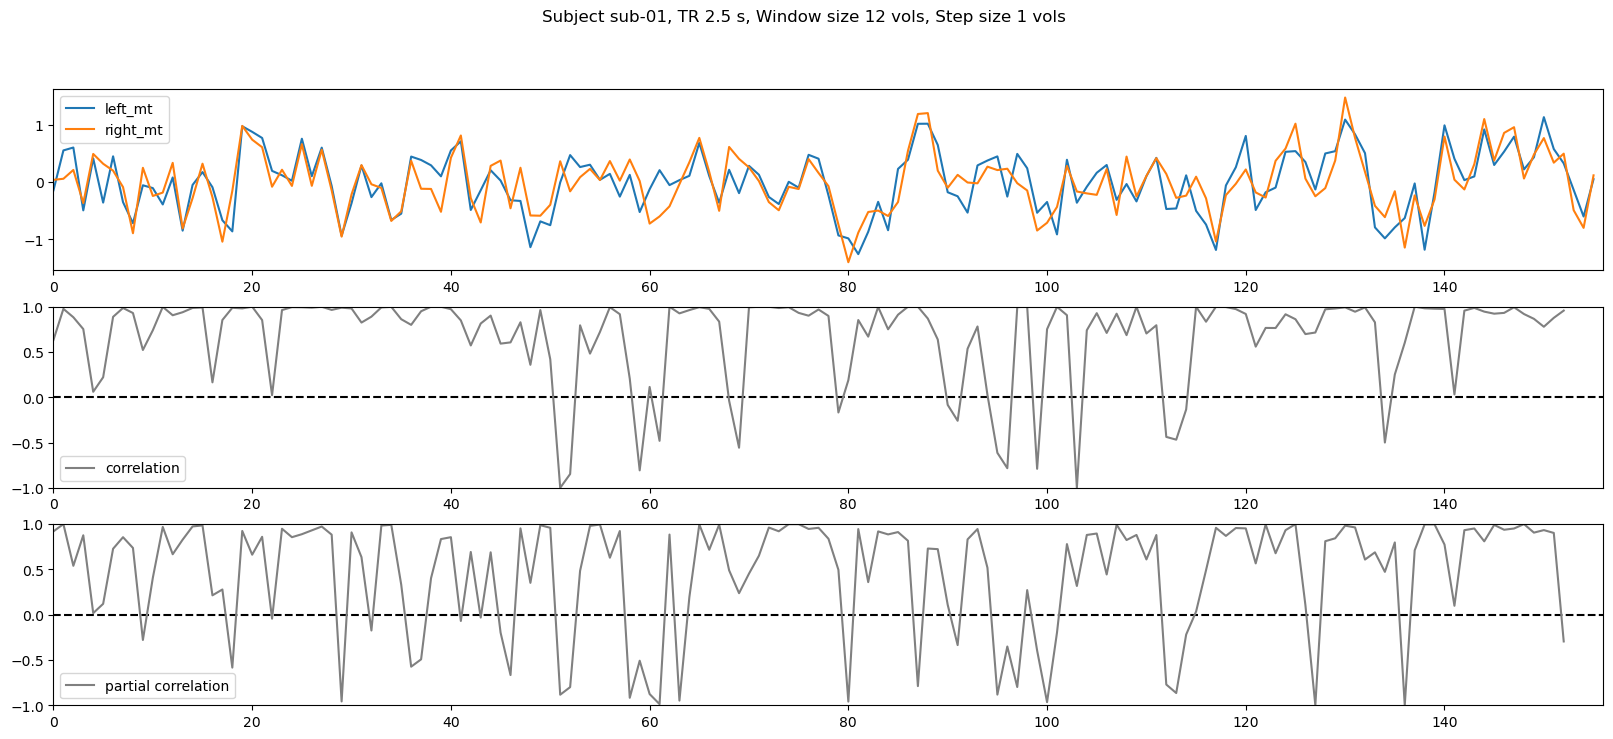

In [6]:
# Plot left mt, right mt and correlation between them as 3 subplots
df_idx = 6

n_volumes = df.loc[df_idx, "left_mt"].shape[0]

fig, ax = plt.subplots(3, 1, figsize=(20, 8))
ax[0].plot(df.loc[df_idx, "left_mt"], label="left_mt")
ax[0].plot(df.loc[df_idx, "right_mt"], label="right_mt")
ax[0].legend()
ax[0].set_xlim([0, n_volumes])
ax[1].hlines(0, 0, n_volumes, linestyle="dashed", color="black")
ax[1].plot(df.loc[df_idx, "corr_mt"], label="correlation", color="grey")
ax[1].legend()
ax[1].set_xlim([0, n_volumes])
ax[1].set_ylim([-1, 1])
ax[2].hlines(0, 0, n_volumes, linestyle="dashed", color="black")
ax[2].plot(df.loc[df_idx, "partial_corr_mt"], label="partial correlation", color="grey")
ax[2].legend()
ax[2].set_xlim([0, n_volumes])
ax[2].set_ylim([-1, 1])

fig.suptitle(f"Subject {df.loc[df_idx, 'subject']}, TR {df.loc[df_idx, 'tr']} s, Window size 12 vols, Step size 1 vols")

# centering at switches

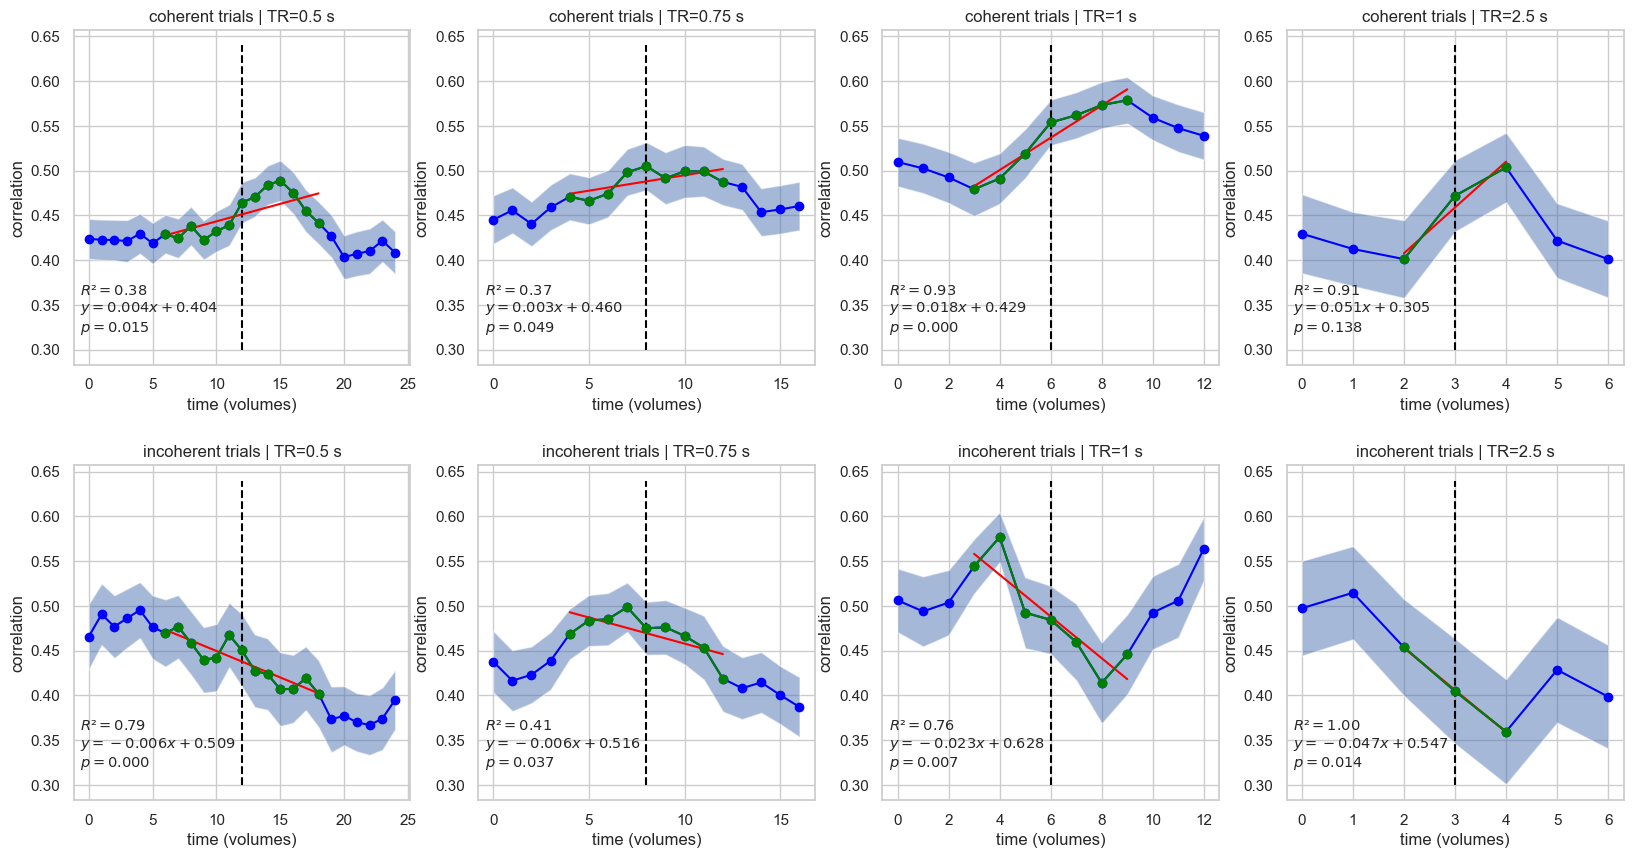

In [29]:
trial_list = ["coherent", "incoherent"]
half_window_size_list = [6, 4, 3, 1]
roi = "mt"

# initialize figure with 4x2 subplot
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
plt.subplots_adjust(hspace=0.3)

for tr_idx, tr in enumerate(tr_list):
    window_size_tr = window_size_tr_list[tr_idx]

    for trial_idx, trial in enumerate(trial_list):
        # fetch correlation values for this tr, roi and trial
        aux = df.loc[df["tr"] == tr, f"corr_{roi}_{trial}"]

        # concatenate all rows
        aux = np.concatenate(aux.values)
        n_samples = aux.shape[0]

        # plot mean and std of aux in subplot
        plt.sca(ax[trial_idx, tr_idx])
        plt.plot(np.mean(aux, axis=0), color="blue", marker="o")
        plt.fill_between(
            range(aux.shape[1]),
            np.mean(aux, axis=0) - np.std(aux, axis=0) / np.sqrt(n_samples),
            np.mean(aux, axis=0) + np.std(aux, axis=0) / np.sqrt(n_samples),
            alpha=0.5,
        )
        plt.vlines(window_size_tr, 0.3, 0.64, linestyle="dashed", color="black")
        # plt.text(8.5,0.7,trial)
        plt.ylabel("correlation")
        plt.xlabel("time (volumes)")
        plt.title(f"{trial} trials | TR={tr} s")

        # add linear regression line
        y = np.mean(aux, axis=0)
        f = half_window_size_list[tr_idx]

        if tr == 2.5:
            y = y[window_size_tr - f : window_size_tr + f + 1]  # pick window for regression
            x = np.arange(f + 1, f + window_size_tr + 1)
        else:
            y = y[window_size_tr - f : window_size_tr + f + 1]  # pick window for regression
            x = np.arange(f, f + y.shape[0])

        # linear regression
        x1 = sm.add_constant(x)

        # fit linear regression model
        model = sm.OLS(y, x1).fit()

        m = model.params[1]
        b = model.params[0]

        # plot
        plt.plot(x, m * x + b, color="red")
        plt.plot(x, y, color="green", marker="o")

        # add text with R squared and p value
        plt.text(
            0.02,
            0.1,
            f"$R\u00b2={model.rsquared_adj:.2f}$\n$y={m:.3f}x + {b:.3f}$\n$p={model.pvalues[1]:.3f}$",
            transform=ax[trial_idx, tr_idx].transAxes,
            fontsize=10.5,
        )

        # plt.ylim([0.28, 0.66])

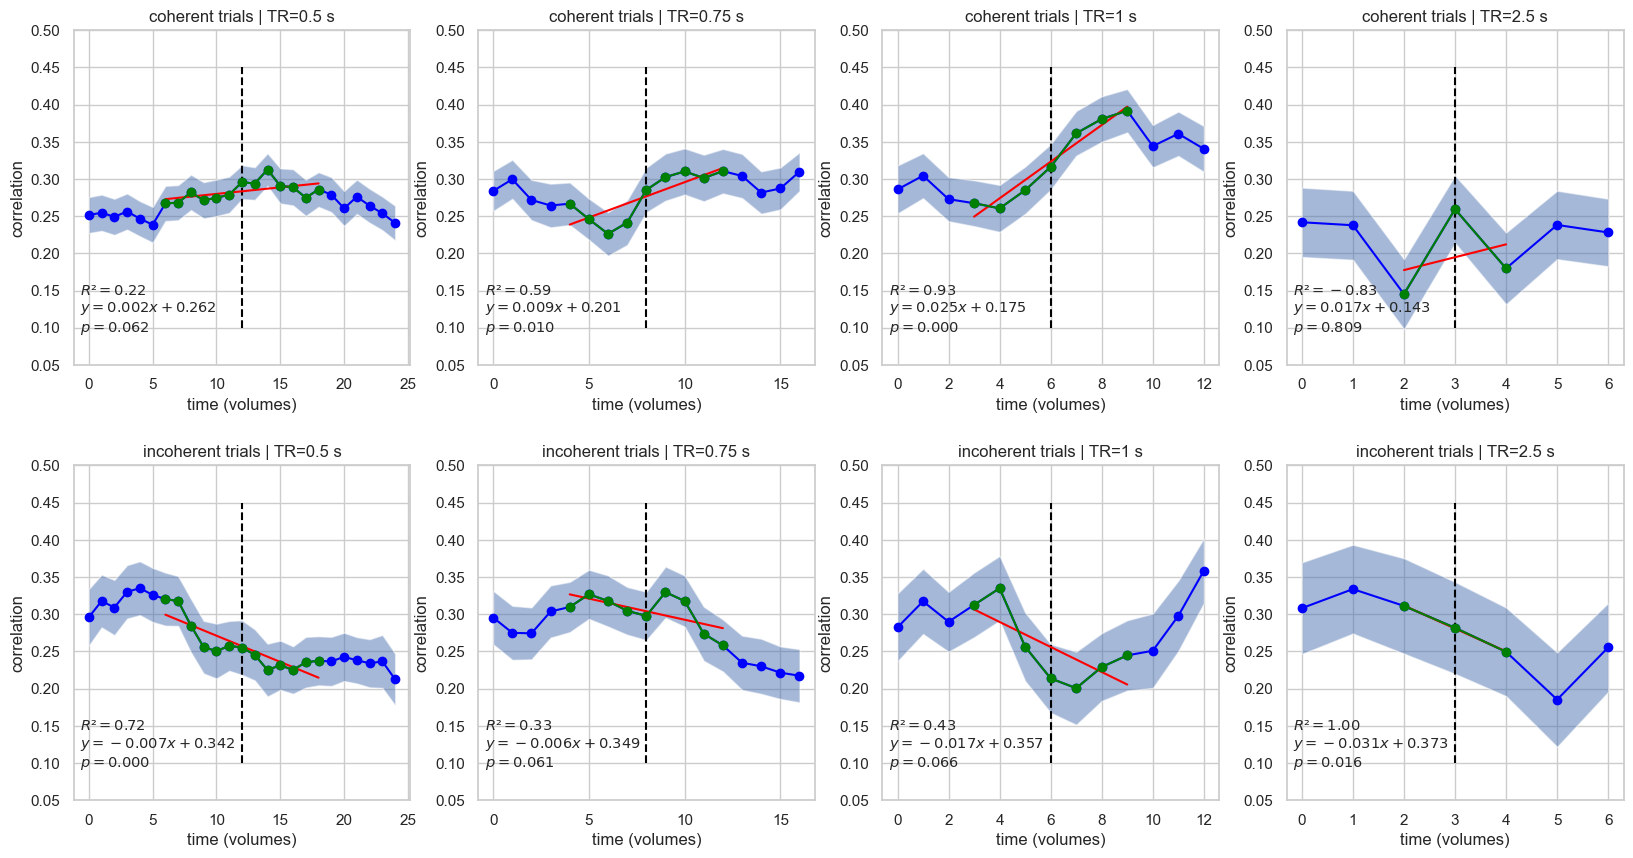

In [30]:
# PARTIAL
#
trial_list = ["coherent", "incoherent"]
half_window_size_list = [6, 4, 3, 1]
roi = "mt"

# initialize figure with 4x2 subplot
fig, ax = plt.subplots(2, 4, figsize=(20, 10))
plt.subplots_adjust(hspace=0.3)

for tr_idx, tr in enumerate(tr_list):
    window_size_tr = window_size_tr_list[tr_idx]

    for trial_idx, trial in enumerate(trial_list):
        # fetch correlation values for this tr, roi and trial
        aux = df.loc[df["tr"] == tr, f"partial_corr_{roi}_{trial}"]

        # concatenate all rows
        aux = np.concatenate(aux.values)
        n_samples = aux.shape[0]

        # plot mean and std of aux in subplot
        plt.sca(ax[trial_idx, tr_idx])
        plt.plot(np.mean(aux, axis=0), color="blue", marker="o")
        plt.fill_between(
            range(aux.shape[1]),
            np.mean(aux, axis=0) - np.std(aux, axis=0) / np.sqrt(n_samples),
            np.mean(aux, axis=0) + np.std(aux, axis=0) / np.sqrt(n_samples),
            alpha=0.5,
        )
        plt.vlines(window_size_tr, 0.1, 0.45, linestyle="dashed", color="black")
        # plt.text(8.5,0.7,trial)
        plt.ylabel("correlation")
        plt.xlabel("time (volumes)")
        plt.title(f"{trial} trials | TR={tr} s")

        # add linear regression line
        y = np.mean(aux, axis=0)
        f = half_window_size_list[tr_idx]

        if tr == 2.5:
            y = y[window_size_tr - f : window_size_tr + f + 1]  # pick window for regression
            x = np.arange(f + 1, f + window_size_tr + 1)
        else:
            y = y[window_size_tr - f : window_size_tr + f + 1]  # pick window for regression
            x = np.arange(f, f + y.shape[0])

        # linear regression
        x1 = sm.add_constant(x)

        # fit linear regression model
        model = sm.OLS(y, x1).fit()

        m = model.params[1]
        b = model.params[0]

        # plot
        plt.plot(x, m * x + b, color="red")
        plt.plot(x, y, color="green", marker="o")

        # add text with R squared and p value
        plt.text(
            0.02,
            0.1,
            f"$R\u00b2={model.rsquared_adj:.2f}$\n$y={m:.3f}x + {b:.3f}$\n$p={model.pvalues[1]:.3f}$",
            transform=ax[trial_idx, tr_idx].transAxes,
            fontsize=10.5,
        )

        plt.ylim([0.05, 0.5])

# dataframe manipulations...

In [9]:
from statannotations.Annotator import Annotator
from itertools import combinations

TRs = [0.5, 0.75, 1, 2.5]
TR_pairs = list(combinations(TRs, r=2))

In [10]:
# convert n_ps_detected_mt_coherent to percentage
df["n_ps_detected_mt_coherent_percent"] = df["n_ps_detected_mt_coherent"] * 100
df["n_ps_detected_mt_incoherent_percent"] = df["n_ps_detected_mt_incoherent"] * 100
df["n_ps_detected_mt_coherent_partial_percent"] = df["n_ps_detected_mt_coherent_partial"] * 100
df["n_ps_detected_mt_incoherent_partial_percent"] = df["n_ps_detected_mt_incoherent_partial"] * 100

In [11]:
# average non zero values of feedback_mt_indexoffirstone_incoherent per subject for each TR
df["feedback_mt_indexoffirstone_coherent_mean"] = df["feedback_mt_indexoffirstone_coherent"].apply(lambda x: np.mean(x[np.nonzero(x)]))
df["feedback_mt_indexoffirstone_incoherent_mean"] = df["feedback_mt_indexoffirstone_incoherent"].apply(lambda x: np.mean(x[np.nonzero(x)]))

# average non zero values of feedback_mt_indexoffirstone_coherent_partial per subject for each TR
df["feedback_mt_indexoffirstone_coherent_partial_mean"] = df["feedback_mt_indexoffirstone_coherent_partial"].apply(
    lambda x: np.mean(x[np.nonzero(x)])
)
df["feedback_mt_indexoffirstone_incoherent_partial_mean"] = df["feedback_mt_indexoffirstone_incoherent_partial"].apply(
    lambda x: np.mean(x[np.nonzero(x)])
)

# convert indexes to seconds based on TR
df["feedback_mt_indexoffirstone_coherent_mean_secs"] = df["feedback_mt_indexoffirstone_coherent_mean"] * df["tr"]
df["feedback_mt_indexoffirstone_incoherent_mean_secs"] = df["feedback_mt_indexoffirstone_incoherent_mean"] * df["tr"]

df["feedback_mt_indexoffirstone_coherent_partial_mean_secs"] = df["feedback_mt_indexoffirstone_coherent_partial_mean"] * df["tr"]
df["feedback_mt_indexoffirstone_incoherent_partial_mean_secs"] = df["feedback_mt_indexoffirstone_incoherent_partial_mean"] * df["tr"]

/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invali

In [12]:
# create new dataframe with df['feedback_mt_indexoffirstone_coherent_mean_secs'] and df['feedback_mt_indexoffirstone_incoherent_mean_secs']
# with a new column named trial type with coeherent and incoherent and the tr as a column

df2 = pd.DataFrame(
    columns=["subject", "tr", "run", "trial_type", "total_number", "n_ps_detected_mt_percent", "feedback_mt_indexoffirstone_mean_secs"]
)

for ss, subject in enumerate(subject_list):
    for tt, tr in enumerate(tr_list):
        for rr, run in enumerate(run_list):
            df2.loc[len(df2)] = [
                subject,
                tr,
                run,
                "coherent",
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_coherent"].values[0],
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_ps_detected_mt_coherent_percent"].values[0],
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "feedback_mt_indexoffirstone_coherent_mean_secs"].values[
                    0
                ],
            ]
            df2.loc[len(df2)] = [
                subject,
                tr,
                run,
                "incoherent",
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_incoherent"].values[0],
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_ps_detected_mt_incoherent_percent"].values[0],
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "feedback_mt_indexoffirstone_incoherent_mean_secs"].values[
                    0
                ],
            ]


In [13]:
df2

,subject,tr,run,trial_type,total_number,n_ps_detected_mt_percent,feedback_mt_indexoffirstone_mean_secs
0,sub-01,0.50,AA,coherent,7,42.857143,2.833333
1,sub-01,0.50,AA,incoherent,2,100.000000,3.500000
2,sub-01,0.50,UA,coherent,7,85.714286,4.166667
3,sub-01,0.50,UA,incoherent,2,100.000000,1.500000
4,sub-01,0.75,AA,coherent,7,85.714286,4.625000
...,...,...,...,...,...,...,...
235,sub-23,1.00,UA,incoherent,0,0.000000,NaN
236,sub-23,2.50,AA,coherent,6,83.333333,4.500000
237,sub-23,2.50,AA,incoherent,0,0.000000,NaN
238,sub-23,2.50,UA,coherent,5,40.000000,5.000000


In [14]:
# create new dataframe with df['feedback_mt_indexoffirstone_coherent_mean_secs'] and df['feedback_mt_indexoffirstone_incoherent_mean_secs']
# with a new column named trial type with coeherent and incoherent and the tr as a column

df2_partial = pd.DataFrame(
    columns=["subject", "tr", "run", "trial_type", "total_number", "n_ps_detected_mt_percent", "feedback_mt_indexoffirstone_mean_secs"]
)

for ss, subject in enumerate(subject_list):
    for tt, tr in enumerate(tr_list):
        for rr, run in enumerate(run_list):
            df2_partial.loc[len(df2_partial)] = [
                subject,
                tr,
                run,
                "coherent",
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_coherent"].values[0],
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_ps_detected_mt_coherent_partial_percent"].values[0],
                df.loc[
                    (df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "feedback_mt_indexoffirstone_coherent_partial_mean_secs"
                ].values[0],
            ]
            df2_partial.loc[len(df2_partial)] = [
                subject,
                tr,
                run,
                "incoherent",
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_incoherent"].values[0],
                df.loc[(df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "n_ps_detected_mt_incoherent_partial_percent"].values[0],
                df.loc[
                    (df["subject"] == subject) & (df["tr"] == tr) & (df["run"] == run), "feedback_mt_indexoffirstone_incoherent_partial_mean_secs"
                ].values[0],
            ]


In [15]:
df2_partial

,subject,tr,run,trial_type,total_number,n_ps_detected_mt_percent,feedback_mt_indexoffirstone_mean_secs
0,sub-01,0.50,AA,coherent,7,71.428571,3.000000
1,sub-01,0.50,AA,incoherent,2,100.000000,3.000000
2,sub-01,0.50,UA,coherent,7,85.714286,5.250000
3,sub-01,0.50,UA,incoherent,2,100.000000,2.500000
4,sub-01,0.75,AA,coherent,7,85.714286,3.250000
...,...,...,...,...,...,...,...
235,sub-23,1.00,UA,incoherent,0,0.000000,NaN
236,sub-23,2.50,AA,coherent,6,50.000000,3.333333
237,sub-23,2.50,AA,incoherent,0,0.000000,NaN
238,sub-23,2.50,UA,coherent,5,80.000000,5.625000


## Number of switches

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



/var/folders/nd/bgqkn02j7sl982jdtqhts9z00000gn/T/ipykernel_6688/800547338.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.boxplot(x="tr", y="total_number", hue="trial_type", palette=cmap, data=df2)


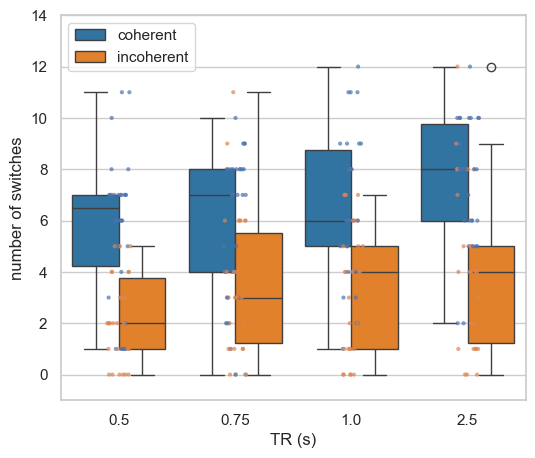

In [16]:
fig = plt.figure(figsize=(6, 5))
cmap = sns.color_palette()
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="total_number", hue="trial_type", palette=cmap, data=df2)

# overlay jittered data points
sns.stripplot(x="tr", y="total_number", data=df2, hue="trial_type", jitter=True, alpha=0.7, size=3)

ax.set_ylabel("number of switches")
ax.set_xlabel("TR (s)")
ax.set_ylim([-1, 14])
# ax.set_yticks([0,20,40,60,80,100])

annotator = Annotator(ax, TR_pairs, data=df2[df2["trial_type"] == "coherent"], x="tr", y="total_number", order=TRs)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction="bonferroni",
    line_offset_to_group=10,
    color=cmap[0],
    hide_non_significant=True,
)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="", loc="upper left")


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04



/var/folders/nd/bgqkn02j7sl982jdtqhts9z00000gn/T/ipykernel_6688/1053309744.py:9: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.boxplot(x="tr", y="total_number", hue="trial_type", palette=cmap, data=df2_partial)


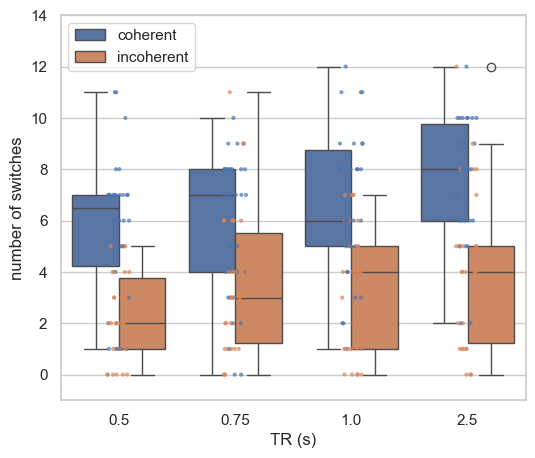

In [17]:
# PARTIAL


fig = plt.figure(figsize=(6, 5))
cmap = sns.color_palette()
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="total_number", hue="trial_type", palette=cmap, data=df2_partial)

# overlay jittered data points
sns.stripplot(x="tr", y="total_number", data=df2_partial, hue="trial_type", jitter=True, alpha=0.7, size=3)

ax.set_ylabel("number of switches")
ax.set_xlabel("TR (s)")
ax.set_ylim([-1, 14])
# ax.set_yticks([0,20,40,60,80,100])

annotator = Annotator(ax, TR_pairs, data=df2_partial[df2_partial["trial_type"] == "coherent"], x="tr", y="total_number", order=TRs)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction="bonferroni",
    line_offset_to_group=10,
    color=cmap[0],
    hide_non_significant=True,
)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="", loc="upper left")

In [18]:
# summary of df2['total_number'] per tr and trial type
df2.groupby(["tr", "trial_type"])["total_number"].describe()

# test for difference between coherent and incoherent trials for each TR
from scipy.stats import ttest_ind

for tr in tr_list:
    print(f"TR {tr}")
    print(
        ttest_ind(
            df2.loc[(df2["tr"] == tr) & (df2["trial_type"] == "coherent"), "total_number"],
            df2.loc[(df2["tr"] == tr) & (df2["trial_type"] == "incoherent"), "total_number"],
        )
    )

TR 0.5
Ttest_indResult(statistic=5.718442429530079, pvalue=3.9497545046216756e-07)
TR 0.75
Ttest_indResult(statistic=3.3512442747661426, pvalue=0.0014201958846792352)
TR 1
Ttest_indResult(statistic=4.762949632428791, pvalue=1.3160868904151752e-05)
TR 2.5
Ttest_indResult(statistic=4.815956954449337, pvalue=1.0893621330605404e-05)


In [19]:
# grand average and standard dev of total_number
df2["total_number"].describe()

count    240.000000
mean       4.875000
std        3.125178
min        0.000000
25%        2.000000
50%        5.000000
75%        7.000000
max       12.000000
Name: total_number, dtype: float64

In [20]:
df["n_total"].describe()

count    120.000000
mean       9.750000
std        3.730974
min        2.000000
25%        7.000000
50%       10.000000
75%       12.250000
max       18.000000
Name: n_total, dtype: float64

# perceptual switch detection rate

In [21]:
# give me n_ps_detected_mt_percent grouped by subject
df2.groupby("trial_type")["n_ps_detected_mt_percent"].describe()

,count,mean,std,min,25%,50%,75%,max
trial_type,,,,,,,,
coherent,120.0,66.997204,25.926040,0.0,50.000000,70.714286,87.5,100.0
incoherent,120.0,80.775794,36.102746,0.0,83.333333,100.000000,100.0,100.0


/var/folders/nd/bgqkn02j7sl982jdtqhts9z00000gn/T/ipykernel_6688/1038223230.py:7: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.boxplot(x="tr", y="n_ps_detected_mt_percent", hue="trial_type", palette=cmap, data=df2)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.511e-04 U_stat=7.340e+02
0.75 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:8.935e-05 U_stat=7.420e+02
0.5 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.621e-04 U_stat=7.325e+02


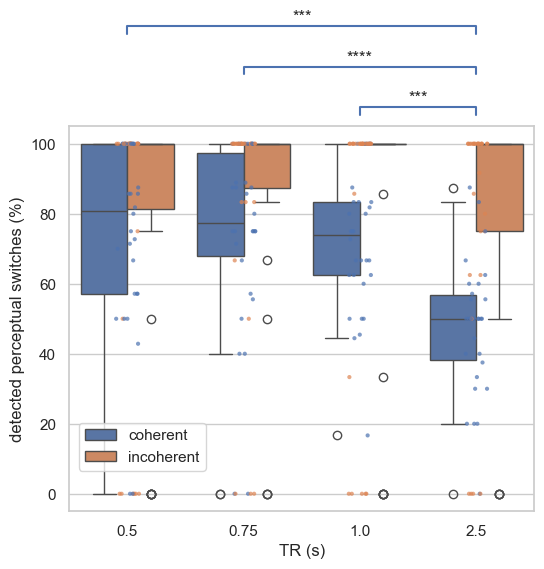

In [22]:
# figure - boxplot of feedback_mt_indexoffirstone_incoherent_mean_secs per TR across subjects using seaborn
fig = plt.figure(figsize=(6, 5))
cmap = sns.color_palette()
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="n_ps_detected_mt_percent", hue="trial_type", palette=cmap, data=df2)

# overlay jittered data points
sns.stripplot(x="tr", y="n_ps_detected_mt_percent", data=df2, hue="trial_type", jitter=True, alpha=0.7, size=3)

ax.set_ylabel("detected perceptual switches (%)")
ax.set_xlabel("TR (s)")
ax.set_yticks([0, 20, 40, 60, 80, 100])

annotator = Annotator(ax, TR_pairs, data=df2[df2["trial_type"] == "coherent"], x="tr", y="n_ps_detected_mt_percent", order=TRs)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction="bonferroni",
    line_offset_to_group=10,
    color=cmap[0],
    hide_non_significant=True,
)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="", loc="upper left", bbox_to_anchor=(0.005, 0.25))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:6.695e-04 U_stat=7.105e+02
0.75 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:5.877e-03 U_stat=6.725e+02
0.5 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.497e-05 U_stat=7.665e+02


/var/folders/nd/bgqkn02j7sl982jdtqhts9z00000gn/T/ipykernel_6688/180563533.py:9: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.boxplot(x="tr", y="n_ps_detected_mt_percent", hue="trial_type", palette=cmap, data=df2_partial)


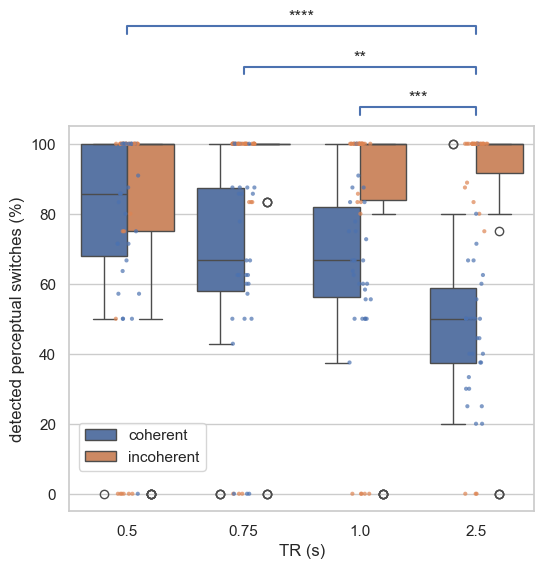

In [23]:
# PARTIAL

# figure - boxplot of feedback_mt_indexoffirstone_incoherent_mean_secs per TR across subjects using seaborn
fig = plt.figure(figsize=(6, 5))
cmap = sns.color_palette()
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="n_ps_detected_mt_percent", hue="trial_type", palette=cmap, data=df2_partial)

# overlay jittered data points
sns.stripplot(x="tr", y="n_ps_detected_mt_percent", data=df2_partial, hue="trial_type", jitter=True, alpha=0.7, size=3)

ax.set_ylabel("detected perceptual switches (%)")
ax.set_xlabel("TR (s)")
ax.set_yticks([0, 20, 40, 60, 80, 100])

annotator = Annotator(ax, TR_pairs, data=df2_partial[df2_partial["trial_type"] == "coherent"], x="tr", y="n_ps_detected_mt_percent", order=TRs)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction="bonferroni",
    line_offset_to_group=10,
    color=cmap[0],
    hide_non_significant=True,
)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="", loc="upper left", bbox_to_anchor=(0.005, 0.25))

In [24]:
# boxplot of n_ps_detected_mt_coherent per TR across subjects
# d = df.loc[df['tr']==1,'n_ps_detected_mt_coherent']

# fig, ax = plt.subplots(1,2,figsize=(10,5),sharey=True)

# sns.set(style="whitegrid")


# sns.boxplot(x='tr',y='n_ps_detected_mt_coherent_percent',data=df,ax=ax[0],palette="vlag")
# sns.boxplot(x='tr',y='n_ps_detected_mt_incoherent_percent',data=df,ax=ax[1],palette="vlag")

# ax[0].set_title('switches to coherent')
# ax[1].set_title('switches to incoherent')
# ax[0].set_ylabel('percentage of identified perceptual switches')
# ax[1].set_ylabel('')

# ax[0].set_xlabel('TR (s)')
# ax[1].set_xlabel('TR (s)')

# ax[0].set_yticks([0,20,40,60,80,100])
# ax[1].set_yticks([0,20,40,60,80,100])

# annotator = Annotator(ax[0], TR_pairs, data=df, x='tr', y='n_ps_detected_mt_coherent', order=TRs)
# annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=1, comparisons_correction='bonferroni', hide_non_significant=True)
# annotator.apply_and_annotate()

# annotator = Annotator(ax[1], TR_pairs, data=df, x='tr', y='n_ps_detected_mt_incoherent', order=TRs)
# annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=1, comparisons_correction='bonferroni', hide_non_significant=True)
# annotator.apply_and_annotate()

# Perceptual switch detection speed

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.473e-06 U_stat=6.665e+02
0.75 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:5.918e-07 U_stat=6.215e+02
0.5 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.023e-09 U_stat=4.230e+02


/var/folders/nd/bgqkn02j7sl982jdtqhts9z00000gn/T/ipykernel_6688/3972627866.py:6: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.boxplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs", palette=cmap, hue="trial_type", data=df2)


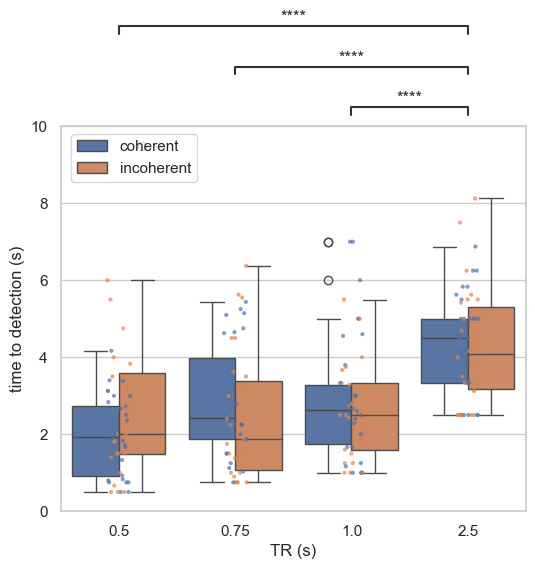

In [25]:
# figure - boxplot of feedback_mt_indexoffirstone_incoherent_mean_secs per TR across subjects using seaborn
fig = plt.figure(figsize=(6, 5))
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs", palette=cmap, hue="trial_type", data=df2)

# overlay jittered data points
sns.stripplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs", data=df2, hue="trial_type", jitter=True, alpha=0.7, size=3)

ax.set_ylabel("time to detection (s)")
ax.set_xlabel("TR (s)")
ax.set_ylim([0, 10])

annotator = Annotator(ax, TR_pairs, data=df2, x="tr", y="feedback_mt_indexoffirstone_mean_secs", order=TRs)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction="bonferroni",
    hide_non_significant=True,
    line_offset_to_group=10,
)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="", loc="upper left", bbox_to_anchor=(0.005, 1))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.330e-09 U_stat=4.785e+02
0.75 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:8.553e-10 U_stat=4.530e+02
0.5 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:4.648e-10 U_stat=4.240e+02


/var/folders/nd/bgqkn02j7sl982jdtqhts9z00000gn/T/ipykernel_6688/3509669409.py:8: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  ax = sns.boxplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs", palette=cmap, hue="trial_type", data=df2_partial)


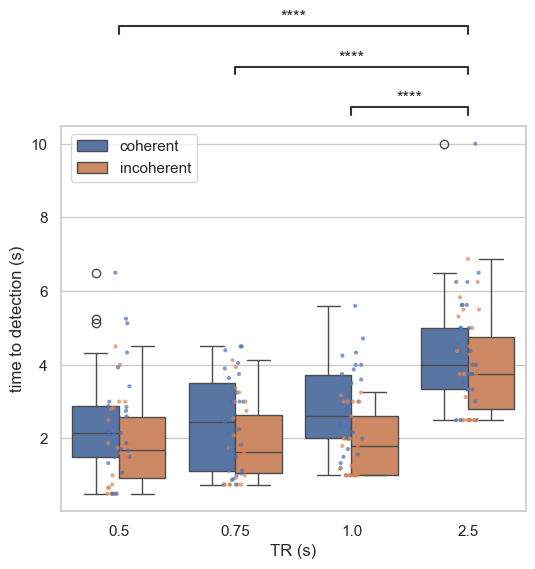

In [26]:
# PARTIAL

# figure - boxplot of feedback_mt_indexoffirstone_incoherent_mean_secs per TR across subjects using seaborn
fig = plt.figure(figsize=(6, 5))
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs", palette=cmap, hue="trial_type", data=df2_partial)

# overlay jittered data points
sns.stripplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs", data=df2_partial, hue="trial_type", jitter=True, alpha=0.7, size=3)

ax.set_ylabel("time to detection (s)")
ax.set_xlabel("TR (s)")

annotator = Annotator(ax, TR_pairs, data=df2_partial, x="tr", y="feedback_mt_indexoffirstone_mean_secs", order=TRs)
annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="outside",
    verbose=1,
    comparisons_correction="bonferroni",
    hide_non_significant=True,
    line_offset_to_group=10,
)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="", loc="upper left", bbox_to_anchor=(0.005, 1))

In [27]:
# Export the matrices used for the "centering at switches" figure
import os
import numpy as np
import pandas as pd

out_dir = os.path.join("..", "results")
os.makedirs(out_dir, exist_ok=True)

trial_list = ["coherent", "incoherent"]
roi = "mt"

for tr in tr_list:
    for trial in trial_list:
        col = f"corr_{roi}_{trial}"
        if col not in df.columns:
            print(f"Column {col} not found in df; skipping TR={tr}.")
            continue

        series = df.loc[df["tr"] == tr, col]
        if len(series) == 0:
            print(f"No rows for TR={tr}, column {col}; skipping.")
            continue

        # stack arrays - each series element may itself be a 2D array (n_trials x timepoints)
        try:
            mats = [np.asarray(x) for x in series.values]
            mat = np.vstack(mats)
        except Exception as e:
            raise RuntimeError(f"Failed to stack arrays for TR={tr}, col={col}: {e}")

        # build matching index labels: repeat subject_run for each trial row in the stacked matrix
        subj_run = df.loc[df["tr"] == tr, ["subject", "run"]].apply(lambda r: f"{r['subject']}_{r['run']}", axis=1).values
        idx_labels = []
        for i, arr in enumerate(mats):
            n_rows = np.asarray(arr).shape[0]
            # append trial-specific labels to match each row of arr
            idx_labels.extend([f"{subj_run[i]}_trial{j}" for j in range(n_rows)])

        if len(idx_labels) != mat.shape[0]:
            raise ValueError(f"Index length ({len(idx_labels)}) does not match stacked matrix rows ({mat.shape[0]}) for TR={tr}, col={col}")

        cols = [f"t{t}" for t in range(mat.shape[1])]
        df_mat = pd.DataFrame(mat, index=idx_labels, columns=cols)

        fname = os.path.join(out_dir, f"{col}_TR{str(tr).replace('.', 'p')}.tsv")
        df_mat.to_csv(fname, sep="\t", index=True)
        print(f"Wrote {fname}")


Wrote ../results/corr_mt_coherent_TR0p5.tsv
Wrote ../results/corr_mt_incoherent_TR0p5.tsv
Wrote ../results/corr_mt_coherent_TR0p75.tsv
Wrote ../results/corr_mt_incoherent_TR0p75.tsv
Wrote ../results/corr_mt_coherent_TR1.tsv
Wrote ../results/corr_mt_incoherent_TR1.tsv
Wrote ../results/corr_mt_coherent_TR2p5.tsv
Wrote ../results/corr_mt_incoherent_TR2p5.tsv


In [28]:
# Export all `corr_mt_*` matrices into a single TSV
import os
import numpy as np
import pandas as pd

out_dir = os.path.join("..", "results")
os.makedirs(out_dir, exist_ok=True)

trial_list = ["coherent", "incoherent"]
roi = "mt"
rows = []
max_len = 0

# collect rows
for tr in tr_list:
    for trial in trial_list:
        col = f"corr_{roi}_{trial}"
        if col not in df.columns:
            continue

        series = df.loc[df["tr"] == tr, col]
        if len(series) == 0:
            continue

        mats = [np.asarray(x) for x in series.values]
        for i, arr in enumerate(mats):
            subj = df.loc[df["tr"] == tr, "subject"].values[i]
            run = df.loc[df["tr"] == tr, "run"].values[i]

            # if arr is 1D -> single trial, if 2D -> multiple trials (n_trials x timepoints)
            if arr.ndim == 1:
                rows.append({"subject": subj, "run": run, "tr": tr, "trial_type": trial, "values": arr})
                if arr.shape[0] > max_len:
                    max_len = arr.shape[0]
            elif arr.ndim == 2:
                for j in range(arr.shape[0]):
                    vals_row = arr[j]
                    rows.append({"subject": subj, "run": run, "tr": tr, "trial_type": trial, "values": vals_row})
                    if vals_row.shape[0] > max_len:
                        max_len = vals_row.shape[0]
            else:
                # unexpected shape, skip
                continue

# convert to DataFrame with padded timepoint columns
records = []
for r in rows:
    vals = np.full(max_len, np.nan, dtype=float)
    if r["values"].size > 0:
        vals[: r["values"].shape[0]] = r["values"]
    rec = {"subject": r["subject"], "run": r["run"], "tr": r["tr"], "trial_type": r["trial_type"]}
    for t_idx in range(max_len):
        rec[f"t{t_idx}"] = vals[t_idx]
    records.append(rec)

if len(records) == 0:
    print("No corr_mt matrices found to export. Run the cells that compute them first.")
else:
    df_all = pd.DataFrame.from_records(records)
    fname = os.path.join(out_dir, "corr_mt_all.tsv")
    df_all.to_csv(fname, sep="\t", index=False)
    print(f"Wrote {fname} with {df_all.shape[0]} rows and {df_all.shape[1]} columns")


Wrote ../results/corr_mt_all.tsv with 1170 rows and 29 columns
